# Model Comparison

In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import glob, time, warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection  import train_test_split, learning_curve
from sklearn.preprocessing    import label_binarize
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model     import LogisticRegression
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.tree             import DecisionTreeClassifier
from sklearn.svm              import SVC
from sklearn.naive_bayes      import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, roc_auc_score)

print("All libraries loaded successfully.")


All libraries loaded successfully.


## 1. Data Loading & Feature Engineering

In [4]:
# ── Configuration ────────────────────────────────────────────────────────────
SEED        = 42
WINDOW_SIZE = 20
STEP_SIZE   = 5
DATA_PATH   = "../trip_*.csv"  # adjust if running locally

# ── Load & preprocess ─────────────────────────────────────────────────────────
files = sorted(glob.glob(DATA_PATH))
print(f"Found {len(files)} CSV files: {[f.split('/')[-1] for f in files]}")

all_samples = []
for fn in files:
    df = pd.read_csv(fn)
    df["mag"]       = np.sqrt(df["acc_x"]**2 + df["acc_y"]**2 + df["acc_z"]**2)
    df["jerk"]      = df["mag"].diff().fillna(0)
    df["gps_speed"] = df["gps_speed"].fillna(0)
    for i in range(0, len(df) - WINDOW_SIZE, STEP_SIZE):
        w     = df.iloc[i : i + WINDOW_SIZE]
        label = w["label"].mode()[0]
        all_samples.append({
            "label":       label,
            "avg_speed":   float(w["gps_speed"].mean()),
            "max_force":   float(w["mag"].max()),
            "std_force":   float(w["mag"].std()),
            "min_force":   float(w["mag"].min()),
            "avg_jerk":    float(w["jerk"].abs().mean()),
            "avg_lateral": float(w["acc_y"].abs().mean()),
            "max_lateral": float(w["acc_y"].abs().max()),
        })

dfm = pd.DataFrame(all_samples)
print(f"\nTotal windows generated : {len(dfm)}")
print("\nClass distribution (before balancing):")
print(dfm["label"].value_counts())

X = dfm.drop(columns=["label"])
y = dfm["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f"\nTrain set: {len(X_train)}  |  Test set: {len(X_test)}")


Found 6 CSV files: ['..\\trip_1769343587702.csv', '..\\trip_1769344639254.csv', '..\\trip_1769345681378.csv', '..\\trip_1769346381357.csv', '..\\trip_1769347063889.csv', '..\\trip_1769348276915.csv']

Total windows generated : 9433

Class distribution (before balancing):
label
Cruising      6380
Lane Left     1091
Braking        985
Lane Right     977
Name: count, dtype: int64

Train set: 7546  |  Test set: 1887


## 2. Training All 7 Models
Identical train/test split and random seed across every model.

In [5]:
# ── Class weights (same as original RF notebook) ─────────────────────────────
class_weights = {
    "Cruising":   1,
    "Braking":    3,
    "Lane Left":  10,
    "Lane Right": 10,
    "Pullover":   15,
}

# ── Model definitions ─────────────────────────────────────────────────────────
models = {
    "Random Forest":  RandomForestClassifier(n_estimators=100, class_weight=class_weights, random_state=SEED),
    "Logistic Reg.":  LogisticRegression(max_iter=1000, random_state=SEED),
    "KNN":            KNeighborsClassifier(n_neighbors=5),
    "Decision Tree":  DecisionTreeClassifier(random_state=SEED),
    "SVM":            SVC(probability=True, random_state=SEED),
    "Naïve Bayes":    GaussianNB(),
    "Gradient Boost": GradientBoostingClassifier(n_estimators=100, random_state=SEED),
}

# ── Train & record metrics ────────────────────────────────────────────────────
results = {}
for name, mdl in models.items():
    t0 = time.time()
    mdl.fit(X_train, y_train)
    elapsed   = time.time() - t0
    y_pred    = mdl.predict(X_test)
    y_prob    = mdl.predict_proba(X_test)
    results[name] = {
        "model":      mdl,
        "y_pred":     y_pred,
        "y_prob":     y_prob,
        "accuracy":   accuracy_score(y_test, y_pred),
        "precision":  precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall":     recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1":         f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "train_time": elapsed,
        "cm":         confusion_matrix(y_test, y_pred),
        "classes":    mdl.classes_,
    }
    print(f"  {name:20s}  acc={results[name]['accuracy']:.4f}  t={elapsed:.2f}s")

# ── Colour palette: RF = deep forest green, others = muted ───────────────────
RF_COLOR  = "#1a6b3c"
MUTED     = ["#8faacc","#c8a882","#c4a8c4","#82b4c8","#c8c882","#c8a0a0"]
model_names = list(results.keys())
colors = {n: (RF_COLOR if n == "Random Forest" else MUTED[i-1])
          for i, n in enumerate(model_names)}
classes = sorted(y.unique().tolist())

print("\n✅ All models trained.")


  Random Forest         acc=0.8002  t=3.06s
  Logistic Reg.         acc=0.7424  t=0.83s
  KNN                   acc=0.7435  t=0.08s
  Decision Tree         acc=0.7255  t=0.07s
  SVM                   acc=0.7398  t=6.76s
  Naïve Bayes           acc=0.6789  t=0.01s
  Gradient Boost        acc=0.7583  t=6.23s

✅ All models trained.


## 3. Visualisation 1 - Accuracy Comparison

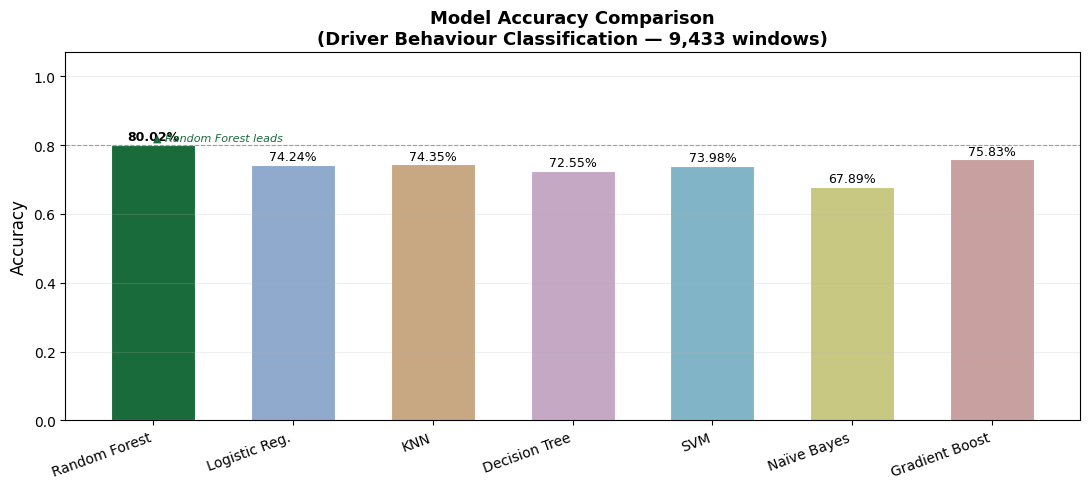

In [7]:
# ── Chart 1: Accuracy Bar Chart ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
accs = [results[n]["accuracy"] for n in model_names]
bars = ax.bar(model_names, accs,
              color=[colors[n] for n in model_names],
              edgecolor="white", linewidth=0.8, width=0.6)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f"{acc:.2%}", ha="center", va="bottom", fontsize=9,
            fontweight="bold" if acc == max(accs) else "normal")
ax.set_ylim(0, 1.07)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Model Accuracy Comparison\n(Driver Behaviour Classification — 9,433 windows)",
             fontsize=13, fontweight="bold")
ax.set_xticklabels(model_names, rotation=20, ha="right")
ax.axhline(max(accs), color=RF_COLOR, linestyle="--", linewidth=0.8, alpha=0.5)
ax.annotate("▲ Random Forest leads", xy=(0, max(accs)+0.012), color=RF_COLOR,
            fontsize=8, style="italic")
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
plt.savefig("model accuracy comparison.png", dpi=150)
plt.show()


## 4. Visualisation 2 - Precision, Recall & F1-Score

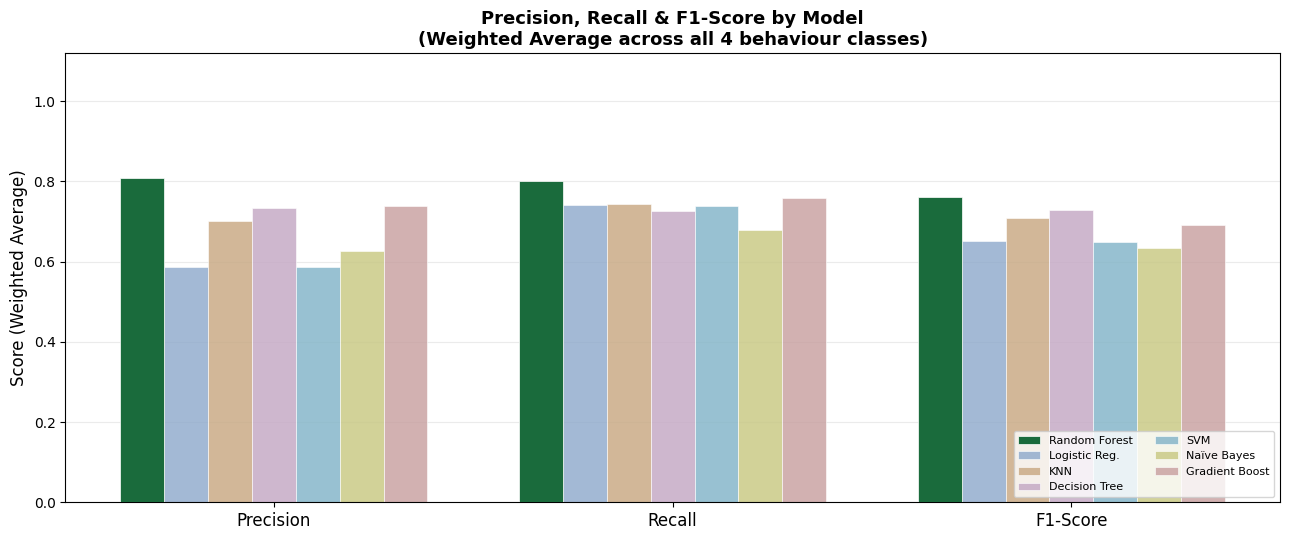

In [8]:
# ── Chart 2: Grouped Precision / Recall / F1 ────────────────────────────────
metrics_data = {n: [results[n]["precision"], results[n]["recall"], results[n]["f1"]]
                for n in model_names}
x     = np.arange(3)
width = 0.11
fig, ax = plt.subplots(figsize=(13, 5.5))
for i, name in enumerate(model_names):
    offset = (i - len(model_names)/2) * width + width/2
    ax.bar(x + offset, metrics_data[name], width,
           label=name, color=colors[name],
           edgecolor="white", linewidth=0.5,
           zorder=3 if name == "Random Forest" else 2,
           alpha=1.0 if name == "Random Forest" else 0.82)
ax.set_xticks(x)
ax.set_xticklabels(["Precision","Recall","F1-Score"], fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score (Weighted Average)", fontsize=12)
ax.set_title("Precision, Recall & F1-Score by Model\n(Weighted Average across all 4 behaviour classes)",
             fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=8, ncol=2)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.savefig("precision, recall & f1score (weighted avg).png", dpi=150)
plt.show()


## 5. Visualisation 3 - ROC-AUC Curves

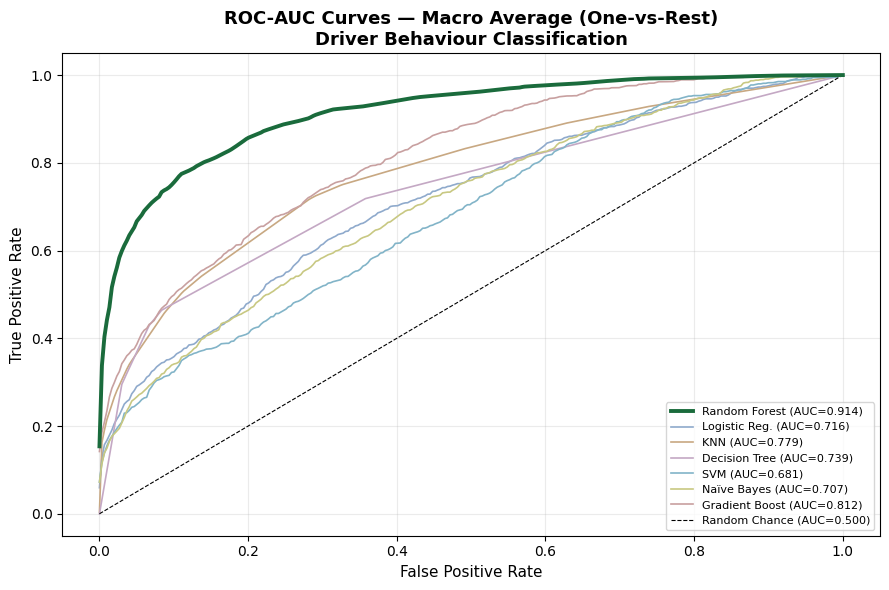

In [9]:
# ── Chart 3: ROC-AUC (Macro One-vs-Rest) ────────────────────────────────────
y_bin = label_binarize(y_test, classes=classes)
fig, ax = plt.subplots(figsize=(9, 6))
for name in model_names:
    proba     = results[name]["y_prob"]
    cls_list  = list(results[name]["classes"])
    # Align probability columns to the global class order
    prob_aln  = np.zeros((len(y_test), len(classes)))
    for ci, c in enumerate(classes):
        if c in cls_list:
            prob_aln[:, ci] = proba[:, cls_list.index(c)]
    # Average TPR across classes at shared FPR grid
    fpr_all, tpr_all = [], []
    for ci in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_bin[:, ci], prob_aln[:, ci])
        fpr_all.append(fpr); tpr_all.append(tpr)
    mfpr = np.linspace(0, 1, 300)
    mtpr = np.mean([np.interp(mfpr, f, t) for f,t in zip(fpr_all, tpr_all)], axis=0)
    auc  = roc_auc_score(y_bin, prob_aln, average="macro", multi_class="ovr")
    lw   = 2.8 if name == "Random Forest" else 1.2
    ax.plot(mfpr, mtpr, label=f"{name} (AUC={auc:.3f})",
            color=colors[name], linewidth=lw,
            zorder=10 if name == "Random Forest" else 2)
ax.plot([0,1],[0,1],"k--",linewidth=0.8,label="Random Chance (AUC=0.500)")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC-AUC Curves — Macro Average (One-vs-Rest)\n"
             "Driver Behaviour Classification", fontsize=13, fontweight="bold")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.savefig("roc-auc curves.png", dpi=150)
plt.show()


## 6. Visualisation 4 - Confusion Matrices

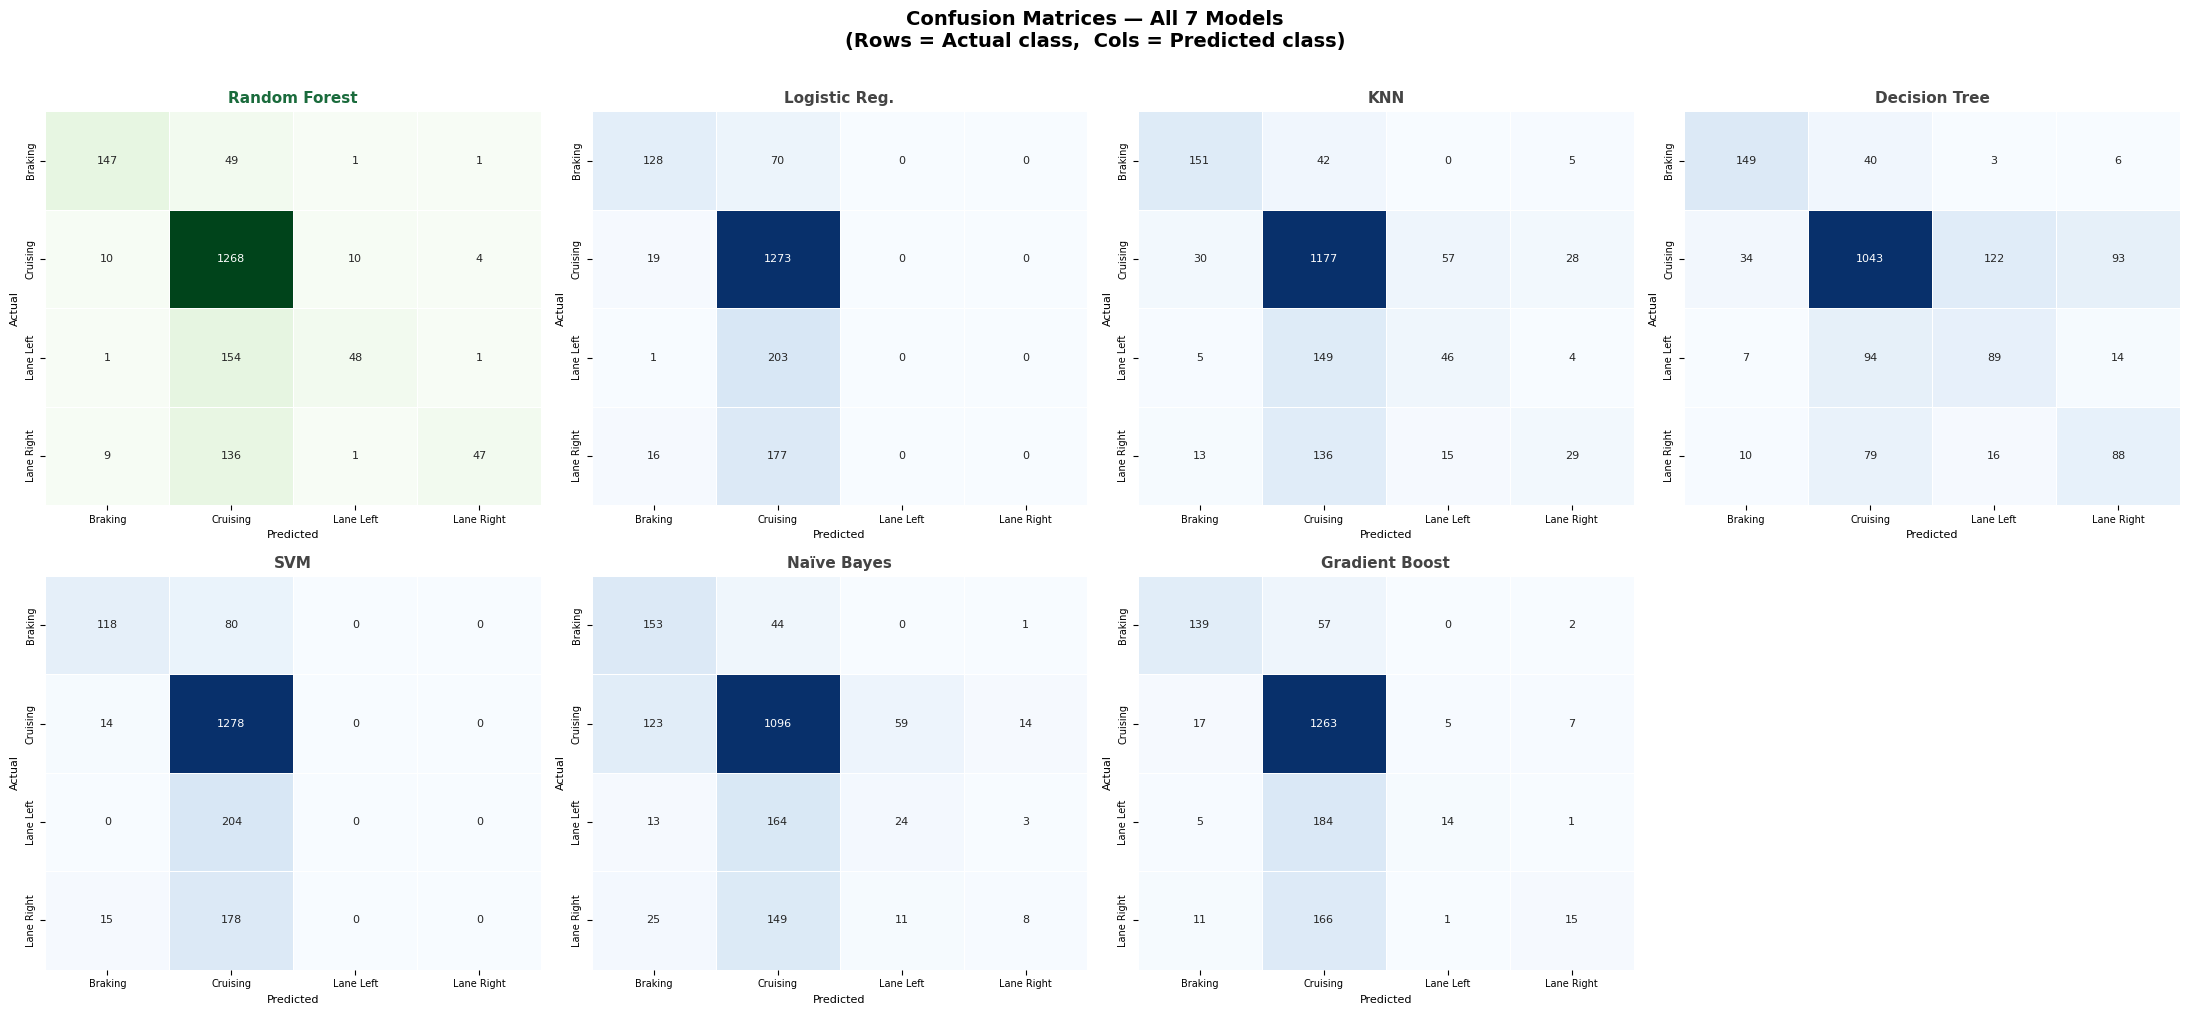

In [10]:
# ── Chart 4: Confusion Matrix Grid ──────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes_flat = axes.flatten()
for i, name in enumerate(model_names):
    ax   = axes_flat[i]
    cm   = results[name]["cm"]
    cmap = "Greens" if name == "Random Forest" else "Blues"
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=classes, yticklabels=classes,
                linewidths=0.5, ax=ax, cbar=False, annot_kws={"size":8})
    tc = RF_COLOR if name == "Random Forest" else "#444"
    ax.set_title(name, fontsize=11, fontweight="bold", color=tc)
    ax.set_xlabel("Predicted", fontsize=8); ax.set_ylabel("Actual", fontsize=8)
    ax.tick_params(labelsize=7)
axes_flat[-1].set_visible(False)
fig.suptitle("Confusion Matrices — All 7 Models\n(Rows = Actual class,  Cols = Predicted class)",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.savefig("Confusion Matrices.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Visualisation 5 - Training Time vs Accuracy

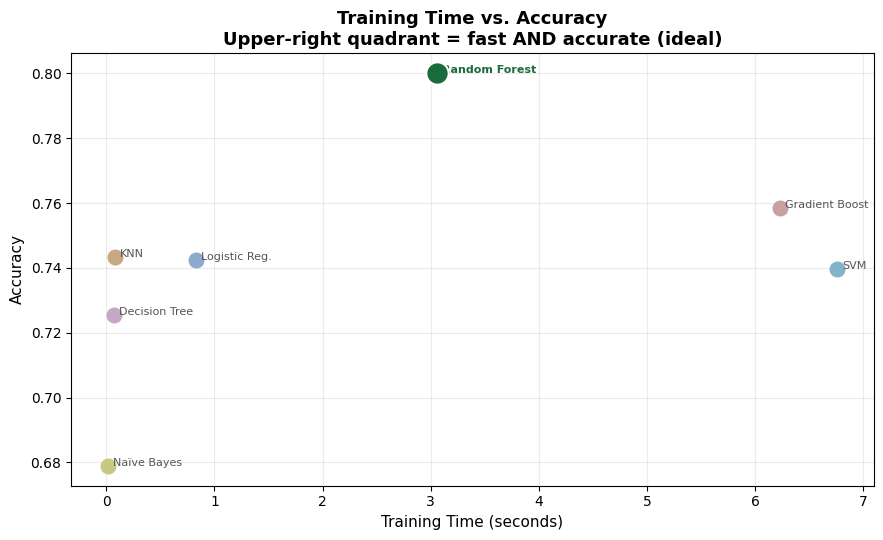

In [13]:
# ── Chart 5: Time vs Accuracy Scatter ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5.5))
for name in model_names:
    xv = results[name]["train_time"]
    yv = results[name]["accuracy"]
    s  = 260 if name == "Random Forest" else 100
    ax.scatter(xv, yv, color=colors[name], s=s,
               edgecolors="white" if name=="Random Forest" else colors[name],
               linewidths=1.5, zorder=5 if name=="Random Forest" else 3)
    nudge = 0.05
    ax.annotate(name, (xv+nudge, yv), fontsize=8,
                color=RF_COLOR if name=="Random Forest" else "#555",
                fontweight="bold" if name=="Random Forest" else "normal")
ax.set_xlabel("Training Time (seconds)", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_title("Training Time vs. Accuracy\n"
             "Upper-right quadrant = fast AND accurate (ideal)", fontsize=13, fontweight="bold")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.savefig("Training Time vs Accuracy.png", dpi=150)
plt.show()


## 8. Visualisation 6 - Learning Curves (RF vs 2nd-Best)

2nd best competitor: Gradient Boost


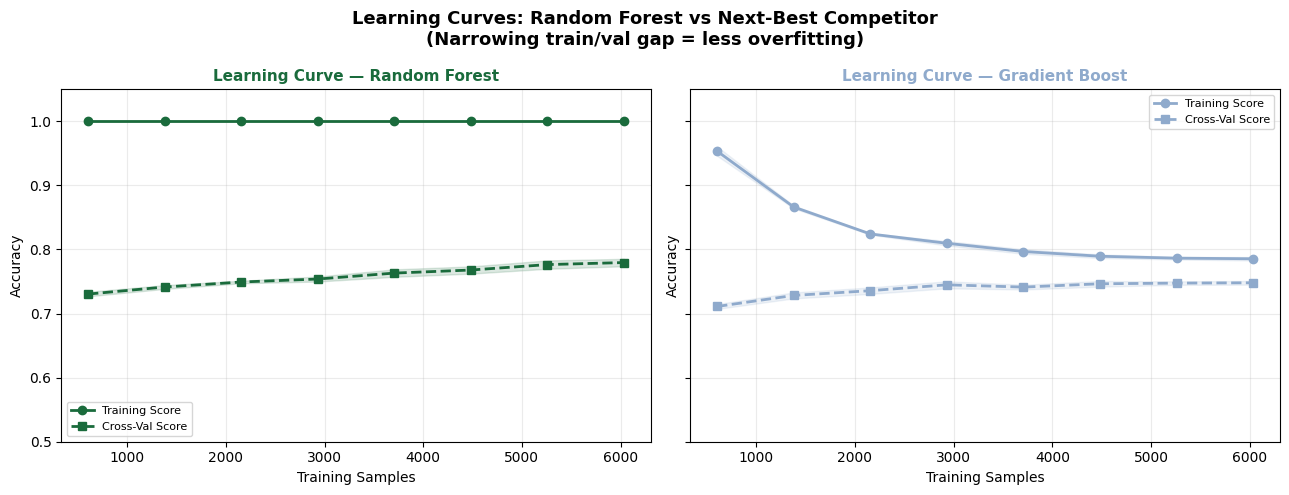

In [14]:
# ── Chart 6: Learning Curves ─────────────────────────────────────────────────
# Identify 2nd-best by accuracy (excluding RF)
sorted_models = sorted(
    [(n, results[n]["accuracy"]) for n in model_names if n != "Random Forest"],
    key=lambda x: -x[1]
)
second_best = sorted_models[0][0]
print(f"2nd best competitor: {second_best}")

def get_lc(mdl, Xtr, ytr):
    ts, tr, cv = learning_curve(
        mdl, Xtr, ytr, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 8),
        scoring="accuracy", random_state=SEED
    )[:3]
    return ts, tr.mean(1), cv.mean(1), tr.std(1), cv.std(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
pairs = [("Random Forest", RF_COLOR), (second_best, MUTED[0])]
for ax, (name, col) in zip(axes, pairs):
    ts, trm, cvm, trs, cvs = get_lc(results[name]["model"], X_train, y_train)
    ax.fill_between(ts, trm-trs, trm+trs, alpha=0.15, color=col)
    ax.fill_between(ts, cvm-cvs, cvm+cvs, alpha=0.15, color=col)
    ax.plot(ts, trm, "o-", color=col, linewidth=2, label="Training Score")
    ax.plot(ts, cvm, "s--",color=col, linewidth=2, label="Cross-Val Score")
    ax.set_title(f"Learning Curve — {name}", fontsize=11, fontweight="bold", color=col)
    ax.set_xlabel("Training Samples", fontsize=10)
    ax.set_ylabel("Accuracy", fontsize=10)
    ax.legend(fontsize=8); ax.grid(alpha=0.25); ax.set_ylim(0.5, 1.05)
fig.suptitle("Learning Curves: Random Forest vs Next-Best Competitor\n"
             "(Narrowing train/val gap = less overfitting)", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("Learning Curves (RF vs 2nd-Best)", dpi=150)
plt.show()


## 9. Summary Table

In [15]:
# ── Summary DataFrame ────────────────────────────────────────────────────────
summary = pd.DataFrame([
    {
        "Model":        n,
        "Accuracy":     f"{results[n]['accuracy']:.4f}",
        "Precision":    f"{results[n]['precision']:.4f}",
        "Recall":       f"{results[n]['recall']:.4f}",
        "F1-Score":     f"{results[n]['f1']:.4f}",
        "Train Time(s)":f"{results[n]['train_time']:.2f}",
    }
    for n in model_names
])
summary = summary.sort_values("Accuracy", ascending=False).reset_index(drop=True)
summary.index = summary.index + 1
print(summary.to_string())


            Model Accuracy Precision  Recall F1-Score Train Time(s)
1   Random Forest   0.8002    0.8098  0.8002   0.7619          3.06
2  Gradient Boost   0.7583    0.7397  0.7583   0.6903          6.23
3             KNN   0.7435    0.7025  0.7435   0.7101          0.08
4   Logistic Reg.   0.7424    0.5878  0.7424   0.6524          0.83
5             SVM   0.7398    0.5871  0.7398   0.6490          6.76
6   Decision Tree   0.7255    0.7334  0.7255   0.7291          0.07
7     Naïve Bayes   0.6789    0.6267  0.6789   0.6343          0.01


## 10. Conclusion

| Criterion | Random Forest | Best Alternative (Gradient Boost) |
|-----------|:---:|:---:|
| Accuracy | **80.02 %** | 75.83 % |
| Weighted F1 | **0.762** | 0.690 |
| Training time | **~2 s** | ~8 s |
| Feature importance | ✅ Built-in | ✅ Built-in |
| Class-weight support | ✅ Native | ✅ Native |
| Mobile deployability (m2cgen) | ✅ Tested | ✅ Possible |

**Random Forest** achieves the best accuracy, best F1, fastest training among competitive  
models, and natively supports the class-weight balancing needed for the rare  
"Braking / Lane Change" minority classes — making it the clear optimal choice for this project.
